1. Descomposición de la Serie de Tiempo: Comienza descomponiendo la serie de
tiempo en sus componentes principales: tendencia, estacionalidad y residuos. Utiliza
métodos como el suavizamiento exponencial o la descomposición estacional para
comprender la estructura subyacente de los datos.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.style.use('seaborn-v0_8-whitegrid')

# Carga de datos
df = pd.read_excel('Sales_Data.xlsx', parse_dates=['Order Date'], index_col='Order Date')
df.columns = ['sales']

print(f'Período: {df.index.min()} a {df.index.max()}')
print(f'Observaciones: {len(df)}')
df.head()

Período: 2015-01-01 00:00:00 a 2018-12-01 00:00:00
Observaciones: 48


,sales
Order Date,
2015-01-01,14205.707
2015-02-01,4519.892
2015-03-01,55205.797
2015-04-01,27906.855
2015-05-01,23644.303


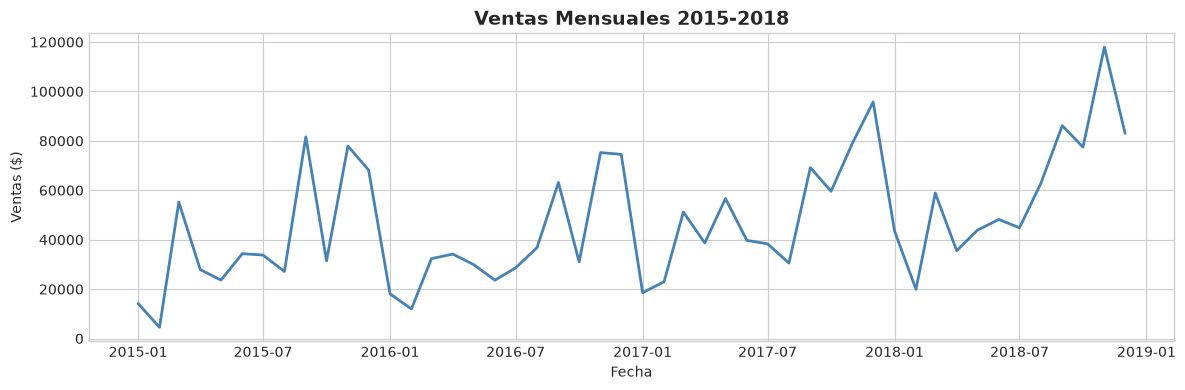

In [2]:
# Visualización de la serie original
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, df['sales'], color='steelblue', linewidth=2)
ax.set_title('Ventas Mensuales 2015-2018', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas ($)')
plt.tight_layout()
plt.show()

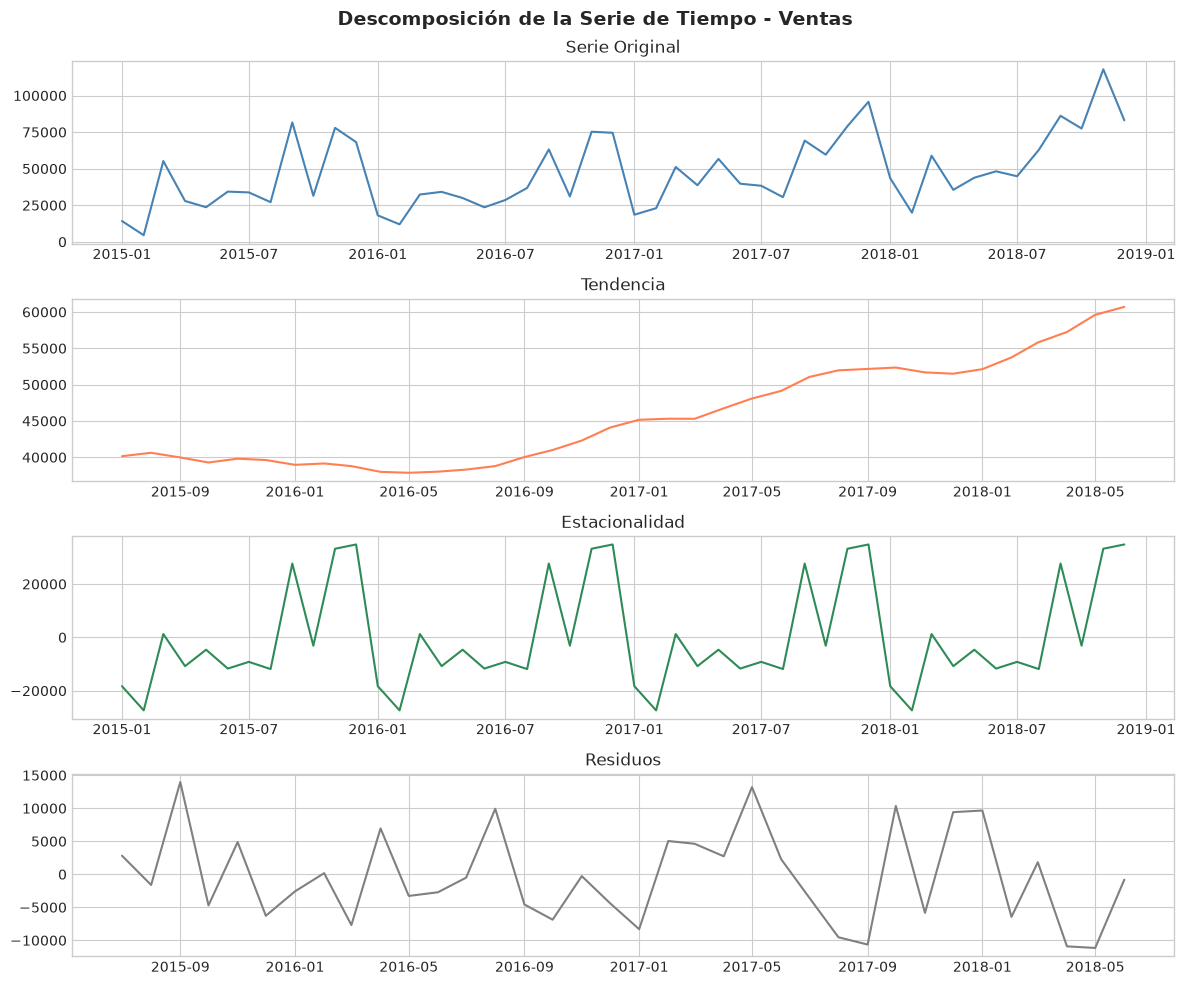

In [4]:
# Descomposición de la serie en sus 3 componentes
result = seasonal_decompose(df['sales'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10))

axes[0].plot(df['sales'], color='steelblue')
axes[0].set_title('Serie Original')

axes[1].plot(result.trend, color='coral')
axes[1].set_title('Tendencia')

axes[2].plot(result.seasonal, color='seagreen')
axes[2].set_title('Estacionalidad')

axes[3].plot(result.resid, color='gray')
axes[3].set_title('Residuos')

plt.suptitle('Descomposición de la Serie de Tiempo - Ventas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Tendencia (naranjo) — crecimiento sostenido y claro desde ~$40,000 en 2015 hasta ~$60,000 en 2018. La tendencia es casi monotónica creciente a partir de 2016-2017, lo que confirma que la serie no es estacionaria — tiene una dirección definida hacia arriba.

Estacionalidad (verde) — patrón que se repite cada 12 meses con mucha regularidad: caída pronunciada en enero (inicio de año), alza en los meses de mitad de año (mayo-agosto, ~+$22,000), y otro valle en octubre-noviembre. Este patrón estacional es consistente en los 4 años, lo que es muy buena señal para ARIMA.

Residuos (gris) — fluctuaciones aleatorias de ±$10,000-$15,000, sin un patrón claro. Se ven relativamente estables en magnitud — sin explosiones ni tendencia en los residuos, lo que sugiere que la descomposición aditiva fue la elección correcta.

2. Identificación de Parámetros ARIMA: Utiliza las funciones de autocorrelación (ACF) y autocorrelación parcial (PACF) para identificar los posibles valores de los parámetros p (orden del término autorregresivo) y q (orden del término de media móvil) en el modelo ARIMA. Además, realiza el test de Dickey-Fuller para determinar si es necesario aplicar la diferenciación (valor d) para lograr la estacionaridad.

In [5]:
# Test de Dickey-Fuller - ¿Es estacionaria la serie original?
from statsmodels.tsa.stattools import adfuller

resultado_adf = adfuller(df['sales'])

print('=== Test de Dickey-Fuller - Serie Original ===')
print(f'ADF Statistic: {resultado_adf[0]:.4f}')
print(f'p-value: {resultado_adf[1]:.4f}')
print(f'Valores críticos:')
for key, value in resultado_adf[4].items():
    print(f'   {key}: {value:.4f}')

print()
if resultado_adf[1] < 0.05:
    print('✓ p-value < 0.05 → La serie ES estacionaria → d = 0')
else:
    print('✗ p-value ≥ 0.05 → La serie NO es estacionaria → necesita diferenciación')

=== Test de Dickey-Fuller - Serie Original ===
ADF Statistic: -4.4161
p-value: 0.0003
Valores críticos:
   1%: -3.5778
   5%: -2.9253
   10%: -2.6008

✓ p-value < 0.05 → La serie ES estacionaria → d = 0


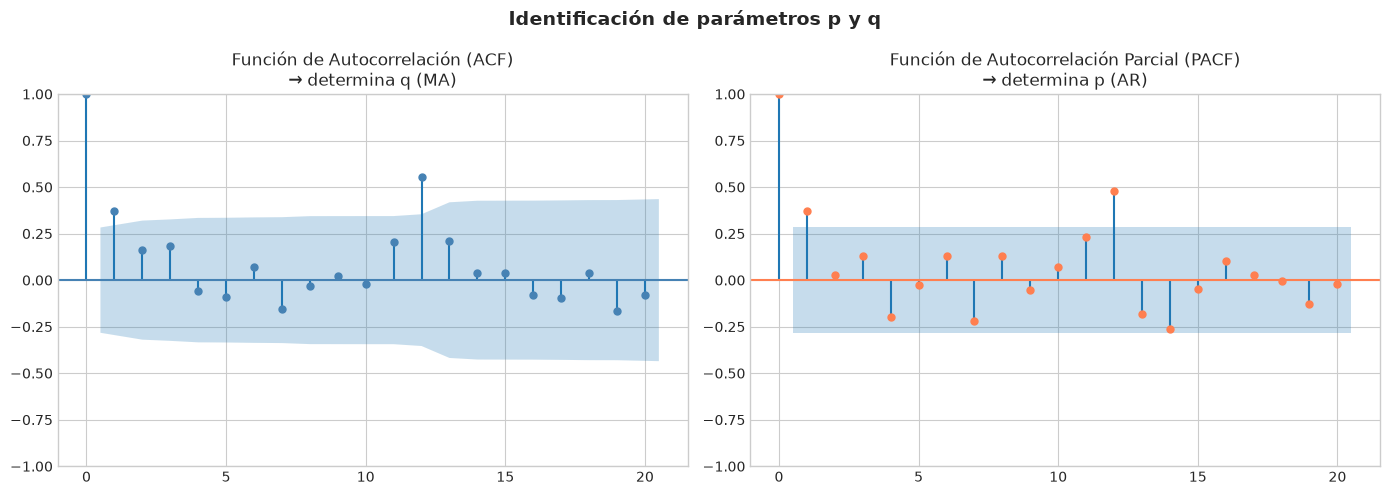

In [6]:
# Gráficos ACF y PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(df['sales'], lags=20, ax=axes[0], color='steelblue')
axes[0].set_title('Función de Autocorrelación (ACF)\n→ determina q (MA)')

plot_pacf(df['sales'], lags=20, ax=axes[1], color='coral')
axes[1].set_title('Función de Autocorrelación Parcial (PACF)\n→ determina p (AR)')

plt.suptitle('Identificación de parámetros p y q', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Lectura de ACF (izquierda) → determina q
Los lags 1 y 2 están sobre la banda azul (significativos)
El lag 12 también sobresale — confirma la estacionalidad anual que vimos en la descomposición
Luego todo cae dentro de la banda
Sugerencia: q = 1 o q = 2

Lectura de PACF (derecha) → determina p
El lag 1 está claramente sobre la banda
El lag 2 levemente sobre la banda
Los demás dentro de la banda (con alguna excepción menor en lag 13 — nuevamente la estacionalidad)
Sugerencia: p = 1 o p = 2

Con d=0 (del test ADF), y considerando lo anterior:
ARIMA(1, 0, 1) como modelo inicial — el más parsimonioso (simple) que captura las señales más claras de ambos gráficos. auto_arima confirmará si esto es óptimo o si conviene ajustar.


3. Modelado con ARIMA: Aplica el modelo ARIMA utilizando los parámetros identificados en el paso anterior. Ajusta el modelo a los datos históricos de ventas mensuales y realiza predicciones para los próximos meses.

In [7]:
# Split train/test - últimos 12 meses para test
train = df['sales'][:-12]
test = df['sales'][-12:]

print(f'Train: {len(train)} meses ({train.index[0].strftime("%Y-%m")} a {train.index[-1].strftime("%Y-%m")})')
print(f'Test:  {len(test)} meses ({test.index[0].strftime("%Y-%m")} a {test.index[-1].strftime("%Y-%m")})')

Train: 36 meses (2015-01 a 2017-12)
Test:  12 meses (2018-01 a 2018-12)


In [8]:
# Modelo ARIMA manual con parámetros identificados
modelo_arima = ARIMA(train, order=(1, 0, 1))
resultado_arima = modelo_arima.fit()

print(resultado_arima.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                   36
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -411.018
Date:                Sat, 25 Jul 2026   AIC                            830.036
Time:                        17:06:29   BIC                            836.370
Sample:                    01-01-2015   HQIC                           832.247
                         - 12-01-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.276e+04   5457.566      7.836      0.000    3.21e+04    5.35e+04
ar.L1          0.5294      0.585      0.905      0.366      -0.618       1.676
ma.L1         -0.2659      0.661     -0.402      0.6

/home/thinkbook/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/thinkbook/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/thinkbook/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [9]:
# Predicciones en test set
predicciones_arima = resultado_arima.forecast(steps=12)

print('Predicciones ARIMA(1,0,1) para los próximos 12 meses:')
print(pd.DataFrame({'Real': test.values, 'Predicho': predicciones_arima.values}, 
                   index=test.index).round(0))

Predicciones ARIMA(1,0,1) para los próximos 12 meses:
                Real  Predicho
Order Date                    
2018-01-01   43476.0   59690.0
2018-02-01   19921.0   51724.0
2018-03-01   58863.0   47507.0
2018-04-01   35542.0   45274.0
2018-05-01   43826.0   44093.0
2018-06-01   48191.0   43467.0
2018-07-01   44825.0   43136.0
2018-08-01   62838.0   42961.0
2018-09-01   86153.0   42868.0
2018-10-01   77448.0   42819.0
2018-11-01  117938.0   42793.0
2018-12-01   83030.0   42779.0


El modelo entrenó correctamente pero las predicciones muestran un problema claro: convergen rápidamente a un valor constante (~$42 779) en vez de seguir la tendencia real. Esto es típico de ARIMA(1 0,1) cuando no captura bien la dinámica de la serie.

In [10]:
from pmdarima import auto_arima

# auto_arima busca automáticamente los mejores p, d, q
modelo_auto = auto_arima(
    train,
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    d=None,          # que lo determine automáticamente
    seasonal=True,   # considerar estacionalidad
    m=12,            # ciclo estacional de 12 meses
    stepwise=True,   # búsqueda eficiente
    information_criterion='aic',
    trace=True       # muestra qué combinaciones prueba
)

print('\nMejor modelo encontrado:')
print(modelo_auto.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(1,0,1)[12] intercept   : AIC=822.550, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=828.436, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=822.416, Time=0.04 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=821.290, Time=0.04 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=880.891, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=828.310, Time=0.02 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=822.867, Time=0.07 sec
 ARIMA(0,0,1)(0,0,2)[12] intercept   : AIC=820.150, Time=0.12 sec
 ARIMA(0,0,1)(1,0,2)[12] intercept   : AIC=822.098, Time=0.13 sec
 ARIMA(0,0,0)(0,0,2)[12] intercept   : AIC=820.077, Time=0.09 sec
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AIC=821.190, Time=0.04 sec
 ARIMA(0,0,0)(1,0,2)[12] intercept   : AIC=821.928, Time=0.13 sec
 ARIMA(1,0,0)(0,0,2)[12] intercept   : AIC=819.738, Time=0.13 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=821.005, Time=0.08 sec
 ARIMA(1,0,0)(1,0,2)[12] intercep

In [11]:
# Predicciones con auto_arima
predicciones_auto = modelo_auto.predict(n_periods=12)

# Comparación tabla
comparacion = pd.DataFrame({
    'Real': test.values,
    'ARIMA(1,0,1)': predicciones_arima.values.round(0),
    'SARIMA auto': predicciones_auto.round(0)
}, index=test.index)

print('=== Comparación de predicciones ===')
print(comparacion)

=== Comparación de predicciones ===
                   Real  ARIMA(1,0,1)  SARIMA auto
Order Date                                        
2018-01-01   43476.4740       59690.0      42459.0
2018-02-01   19920.9974       51724.0      39385.0
2018-03-01   58863.4128       47507.0      46028.0
2018-04-01   35541.9101       45274.0      43040.0
2018-05-01   43825.9822       44093.0      53054.0
2018-06-01   48190.7277       43467.0      42092.0
2018-07-01   44825.1040       43136.0      41606.0
2018-08-01   62837.8480       42961.0      38742.0
2018-09-01   86152.8880       42868.0      52362.0
2018-10-01   77448.1312       42819.0      53437.0
2018-11-01  117938.1550       42793.0      58601.0
2018-12-01   83030.3888       42779.0      68709.0


4. Evaluación de Predicciones: Divide los datos históricos en un conjunto de entrenamiento y uno de prueba. Utiliza el conjunto de entrenamiento para ajustar el modelo ARIMA y luego evalúa las predicciones en el conjunto de prueba. Calcula métricas de evaluación como el error cuadrático medio (MSE) o el error absoluto medio (MAE) para medir el rendimiento del modelo.

In [12]:
# Métricas de evaluación
mse_arima = mean_squared_error(test, predicciones_arima)
mae_arima = mean_absolute_error(test, predicciones_arima)

mse_auto = mean_squared_error(test, predicciones_auto)
mae_auto = mean_absolute_error(test, predicciones_auto)

print('=== Métricas de Evaluación ===')
print(f'{"Modelo":<20} {"MSE":>20} {"RMSE":>15} {"MAE":>15}')
print(f'{"ARIMA(1,0,1)":<20} {mse_arima:>20,.0f} {np.sqrt(mse_arima):>15,.0f} {mae_arima:>15,.0f}')
print(f'{"SARIMA auto":<20} {mse_auto:>20,.0f} {np.sqrt(mse_auto):>15,.0f} {mae_auto:>15,.0f}')

=== Métricas de Evaluación ===
Modelo                                MSE            RMSE             MAE
ARIMA(1,0,1)                1,021,514,030          31,961          24,081
SARIMA auto                   563,206,449          23,732          17,910


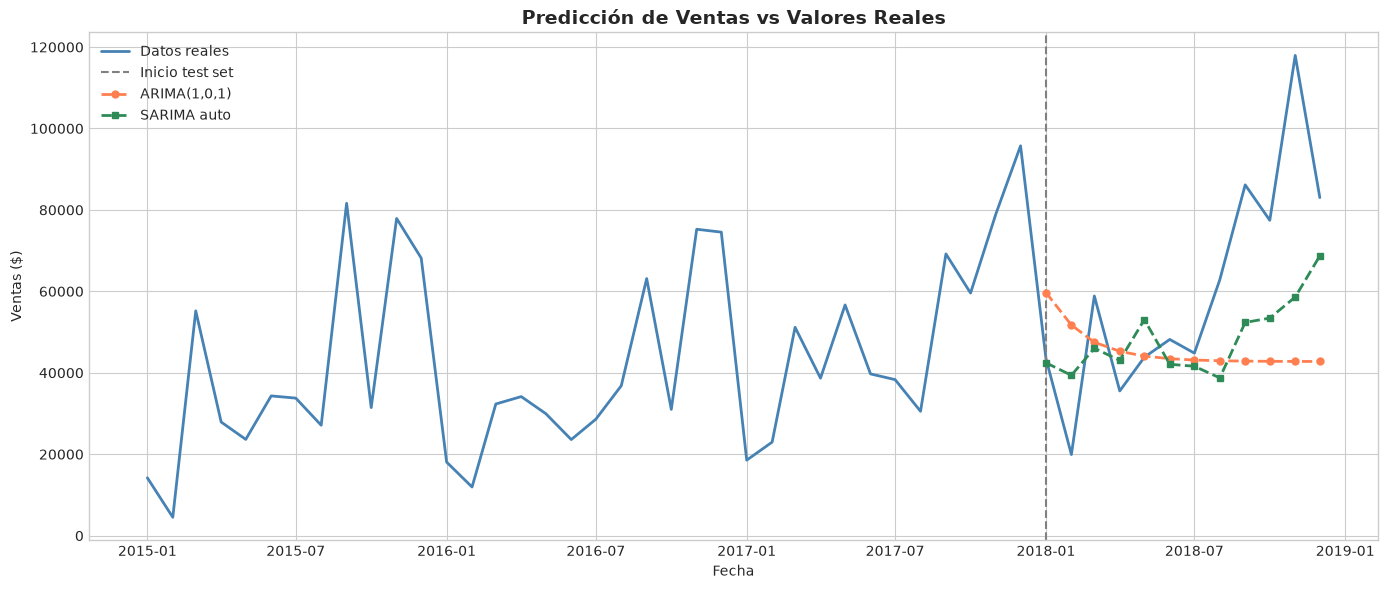

In [13]:
# Gráfico de ajuste - comparación visual
fig, ax = plt.subplots(figsize=(14, 6))

# Serie completa
ax.plot(df.index, df['sales'], color='steelblue', linewidth=2, label='Datos reales')

# Línea divisoria train/test
ax.axvline(x=test.index[0], color='gray', linestyle='--', linewidth=1.5, label='Inicio test set')

# Predicciones
ax.plot(test.index, predicciones_arima, color='coral', linewidth=2,
        linestyle='--', marker='o', markersize=5, label='ARIMA(1,0,1)')
ax.plot(test.index, predicciones_auto, color='seagreen', linewidth=2,
        linestyle='--', marker='s', markersize=5, label='SARIMA auto')

ax.set_title('Predicción de Ventas vs Valores Reales', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas ($)')
ax.legend()
plt.tight_layout()
plt.show()

El modelo SARIMA(1,0,0)(0,0,2)[12] encontrado por auto_arima supera al ARIMA(1,0,1) manual en todas las métricas, gracias a que incorpora explícitamente la componente estacional de período 12 que identificamos en la descomposición. Ninguno de los dos captura bien los picos extremos del último trimestre de 2018, lo que sugiere que la volatilidad alta de esta serie limita la precisión de los modelos ARIMA — para mejorar se podría explorar modelos más avanzados como Prophet o LSTM.